In [3]:
import os
import sys
import numpy as np
from gen_graph import gen_plots

# custom imports
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
from soft_threshold_host import train_soft
from data_proc.parse_audio_data import parse_audio, save_audio

import pickle
import matplotlib.pyplot as plt

N = 30000
with open("../data/train_set.pickle", "rb") as f:
    train_set = pickle.load(f)

with open("../data/test_set.pickle", "rb") as f:
    test_set = pickle.load(f)

train_x = [i[0] for i in train_set]
train_y = [i[1] for i in train_set]

thresh, scale, loss_hist = train_soft(train_x, train_y, N, lr=1e-7, epochs=100)


Reverse differentiation of function rev_soft_thresh_loss:
def rev_soft_thresh_loss(noisy : In[Array[float]], _dnoisy_9GowQx : Out[Array[float]], clean : In[Array[float]], _dclean_kSa9cy : Out[Array[float]], threshold : In[float], _dthreshold_XpQsdz : Out[float], scale : In[float], _dscale_4Hkk1x : Out[float], N : In[int], _dN_mct69x : Out[int], _dreturn_JPNuy1 : In[float]) -> void:
	_t_float_h2XWUs : Array[float, 561000]
	_stack_ptr_float_h2XWUs : int = (int)(0)
	_t_int_NGpu6z : Array[int, 153000]
	_stack_ptr_int_NGpu6z : int = (int)(0)
	_loop_var_0_OQ6tS6 : int
	_call_t_0_PYT6vp : int
	_call_t_2_G3TaSl : float
	_d_call_t_2_G3TaSl_fQAQ7M : float
	_call_t_3_2VobLO : int
	_call_t_5_Kgleub : float
	_d_call_t_5_Kgleub_yZ4av0 : float
	loss : float = (float)(0.0)
	_dloss_0gB7VV : float
	i : int = (int)(0)
	val : float = (float)(0.0)
	_dval_Eh0qs2 : float
	abs_val : float = (float)(0.0)
	_dabs_val_sLeTeu : float
	sign : float = (float)(0.0)
	_dsign_5gHRUx : float
	out_val : float = (float)(0

training...:   1%|          | 1/100 [00:00<00:26,  3.71it/s]

Epoch 0 | Loss: 467.0977


training...:  11%|█         | 11/100 [00:02<00:22,  3.92it/s]

Epoch 10 | Loss: 184.9566


...

Epoch 80 | Loss: 113.1731


training...:  91%|█████████ | 91/100 [00:25<00:02,  3.33it/s]

Epoch 90 | Loss: 112.9363


training...: 100%|██████████| 100/100 [00:28<00:00,  3.52it/s]

final loss: 112.97797301899304


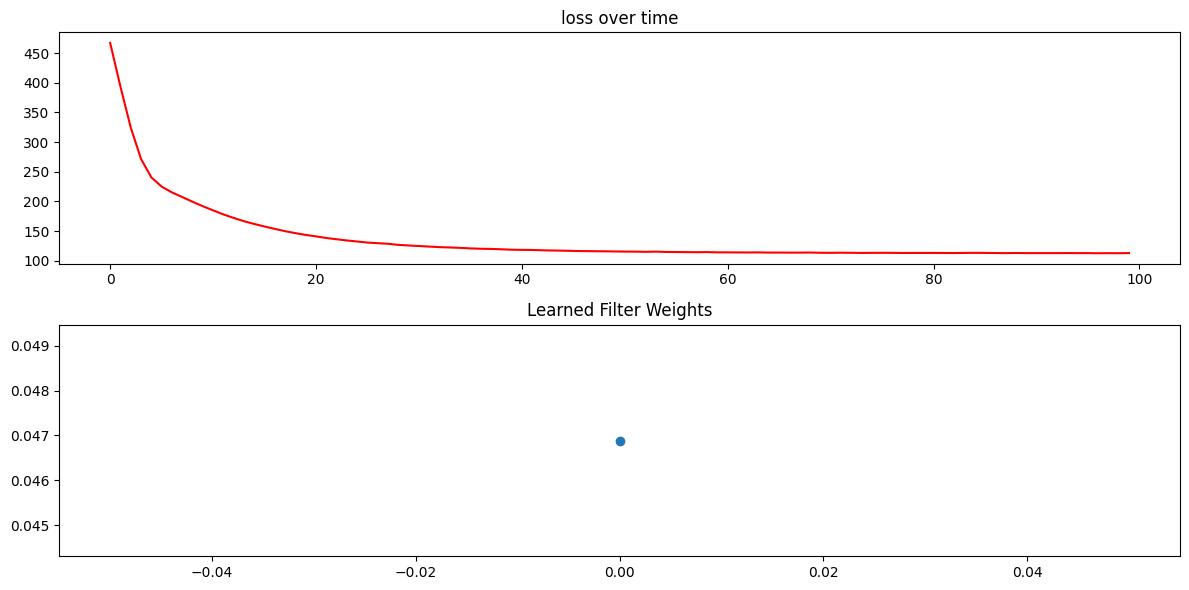

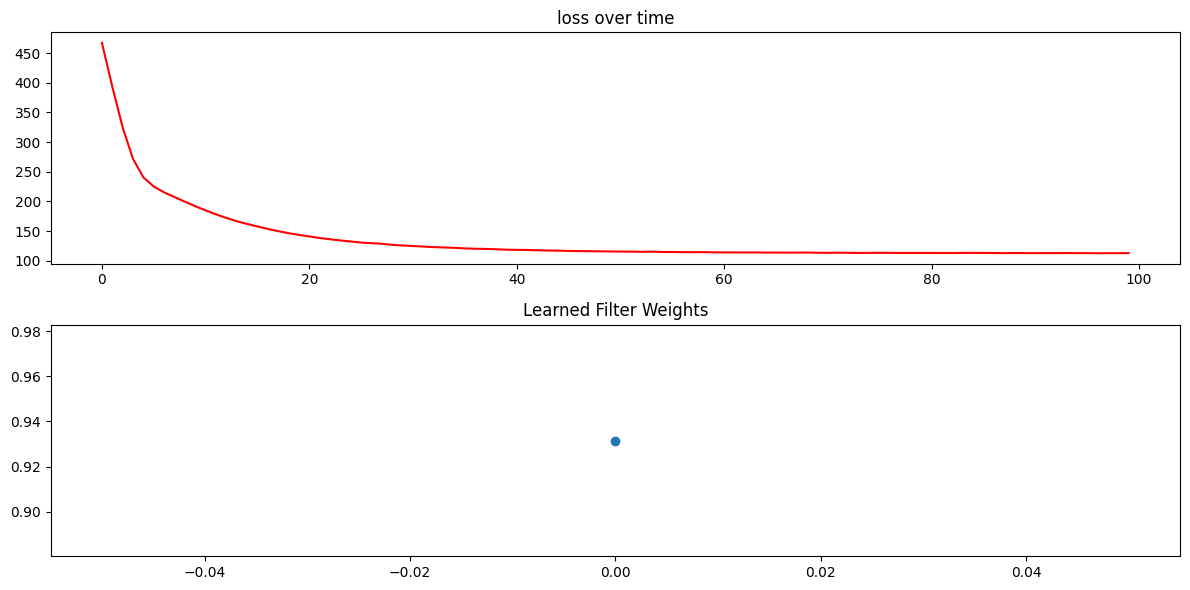

In [4]:
gen_plots(thresh, loss_hist)
gen_plots(scale, loss_hist)

saved audio to: ../data/soft_generated.wav


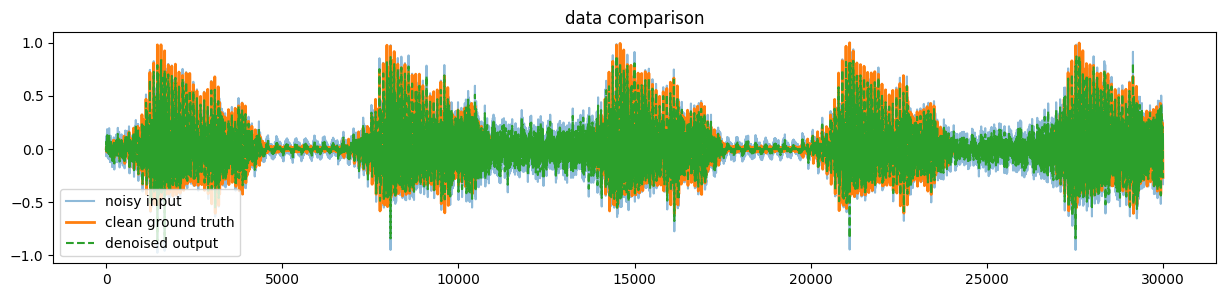

In [5]:
import random

# peak at some samples
def peak_sample_perf(noisy_sample, clean_sample, thresh, scale):
    plt.figure(figsize=(15, 3))
    # example for one data snippet
    abs_audio = np.abs(noisy_sample)
    sign_audio = np.sign(noisy_sample)
    gate_mask = abs_audio > thresh
    denoised_audio = gate_mask * sign_audio * (abs_audio - thresh) * scale

    save_audio(denoised_audio, 16000, output_path="../data/soft_generated.wav")

    plt.title("data comparison")
    plt.plot(noisy_sample, label="noisy input", alpha=0.5)
    plt.plot(clean_sample, label="clean ground truth", linewidth=2)
    plt.plot(denoised_audio, label="denoised output", linestyle='--')
    plt.legend()

    plt.show()

test_x = [i[0] for i in test_set]
test_y = [i[1] for i in test_set]

r = random.randint(1, 50)
peak_sample_perf(test_x[r], test_y[r], thresh, scale)

In [7]:
# calc average test set MSE
def calc_loss(eval_x, eval_y, thresh, scale):
    K = 20
    total_mse = 0.0
    for x, y in zip(eval_x, eval_y):
        abs_audio = np.abs(x)
        sign_audio = np.sign(x)
        gate_mask = abs_audio > thresh
        denoised_audio = gate_mask * sign_audio * (abs_audio - thresh) * scale

        mse = np.sum((denoised_audio - y) ** 2)
        total_mse += mse

    # Return the average MSE across all files in the dataset
    return total_mse / len(eval_x)

print(calc_loss(test_x, test_y, thresh, scale))
print(calc_loss(train_x, train_y, thresh, scale))

138.17047
112.882286
